Lab 2

This lab will focus on the Jaynes-Cumming Model (JCM) used to describe the interaction between a  single electromagnetic mode and a two-levelsystem (TLS) confined in a cavity.

The JCM is used to describe a superconducting qubit coupled to a microwavecavity.  In this set of exercises you will explore the relation between the qubit-cavity detuning ($\Delta$), controlled by an external parameter such as flux or gate voltage, the qubit-cavity coupling rate (g), and the losses in the qubit ($\gamma$) and cavity ($\kappa$ and $\bar{n}$).

Import qutip and other packages

In [1]:
# setup the matplotlib graphics library and configure it to show 
# figures inline in the notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt as sqrt
from numpy import pi as pi

# make qutip available in the rest of the notebook
from qutip import *

# Exercise 1

Create a general system based on the Jaynes-Cumming model, evolve the
state and visualize the results.
[QuTiP Lecture 1 - JCM](https://github.com/jrjohansson/qutip-lectures/blob/master/Lecture-1-Jaynes-Cumming-model.ipynb)

## General JCM

Use the following parameters to create a system based on the general JCM.

The hamiltonian for this system is:
$H = \hbar\omega_c a^\dagger a + \frac{1}{2}\hbar\omega_a \sigma_z + \hbar g\left(a^{\dagger}+a\right)\left(\sigma_{-}+\sigma_{+}\right)$

[QuTiP Quantum Operators](https://qutip.org/docs/latest/apidoc/functions.html?highlight=qutip%20operators#module-qutip.operators)

In [2]:
fc = 1.0            # cavity frequency
fa = 1.0            # atom frequency
g  = 0.05           # coupling strength
kappa = 0.005       # cavity dissipation rate
gamma = 0.05        # atom dissipation rate
N = 15              # number of cavity fock states
n_th_a = 0.0        # avg number of thermal bath excitation

Type your codes here

In [3]:
wc = 1.0 * 2 * np.pi  #cavity frequency
wa = 1.0 * 2 * np.pi  #atom frequency
g = 0.05 * 2 * np.pi  #coupling strength

use_rwa = True
time = np.linspace(0,25,100)  #time evolution

In [4]:
#initial state
psi0 = tensor(basis(N,0), basis(2,1)) #start in the excited state(atom) and vacuum state(cavity)

#operators
a = tensor(destroy(N), qeye(2))  #annihilation operator on cavity
sigmam = tensor(qeye(N), destroy(2))  #annihilation operator on atom

#Hamiltonian
if use_rwa:
    H = wc * a.dag() * a + wa * sigmam.dag() * sigmam + g * (a.dag() * sigmam + a * sigmam.dag())
else:
    H = wc * a.dag() * a + wa * sigmam.dag() * sigmam + g * (a.dag() + a) * (sigmam.dag() + sigmam)

## Collapse Operators

Create the collapse operators from the losses ($\gamma$, $\kappa$ and $\bar{n}$) in the system. <br>

Remember in the session 1, you have created the collapse operators for harmonic oscillator. In this exercise, you not only need to consider the cavity (harmonic oscillator) but also the atom-like state. For the atom-like state, the collapse operator is given by $\sqrt{\gamma}\sigma_{-}$.

Type your codes here

In [11]:
#collapse operators, describing dissipation
c_ops = []

#cavity relaxation/ decay
#if cavity coupled to a thermal bath, characterized by thermal noise n_th
#photon emitted to thermal bath
rate1 = kappa * (1 + n_th_a)
if rate1 > 0:
    c_ops.append(np.sqrt(rate1) * a)

#cavity excitation
#photon absorbed from thermal bath
rate2 = kappa * n_th_a
if rate2 > 0:
    c_ops.append(np.sqrt(rate2) * a.dag())

#atom relaxation/ decay
rate3 = gamma
if rate3 > 0:
    c_ops.append(np.sqrt(rate3) * sigmam)


## Evolve the system

Use the built-in function [mesolve](https://qutip.org/docs/latest/apidoc/functions.html?highlight=mesolve#module-qutip.mesolve) to simulate how the system evolves from a user-defined initial state looking at the expectation values of $a^{\dagger}a$ and $\sigma_{+}\sigma_{-}$

Type your codes here

In [12]:
#solve master equation
result = mesolve(H, psi0, time, c_ops, [a.dag() * a, sigmam.dag() * sigmam])
#return a.dag()*a and sigmam.dag()*sigmam expectation values

Visualise the atom's and cavity's excitation probabilities

Type your codes here

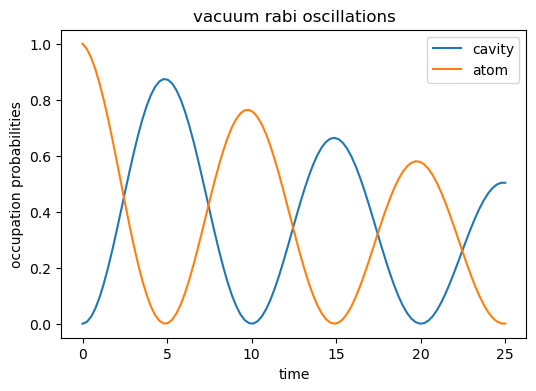

In [15]:
#vacuum rabi oscillations with dissipation
n_c = result.expect[0]  #expectation value for cavity occupation number
n_a = result.expect[1]  #expectation value for atom occupation number

fig, axe = plt.subplots(1,1, figsize = (6,4))
axe.plot(time, n_c, label = 'cavity')
axe.plot(time, n_a, label = 'atom')
axe.legend(loc = 0)
axe.set_xlabel('time')
axe.set_ylabel('occupation probabilities')
axe.set_title('vacuum rabi oscillations')

plt.show()

Now explore how the excitation probabilities change when $\kappa$ and $\gamma$ change

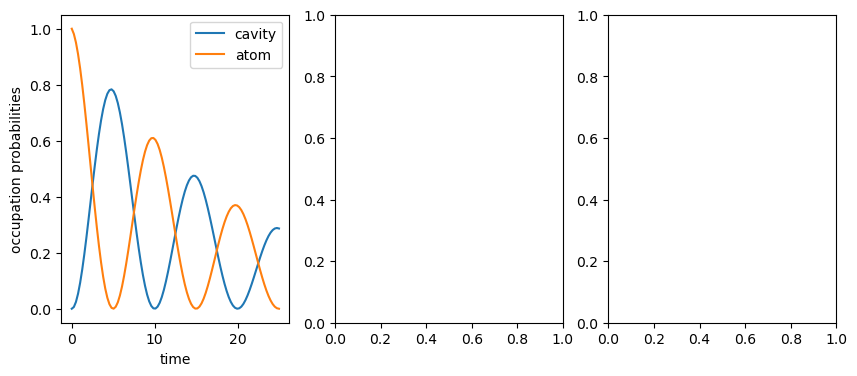

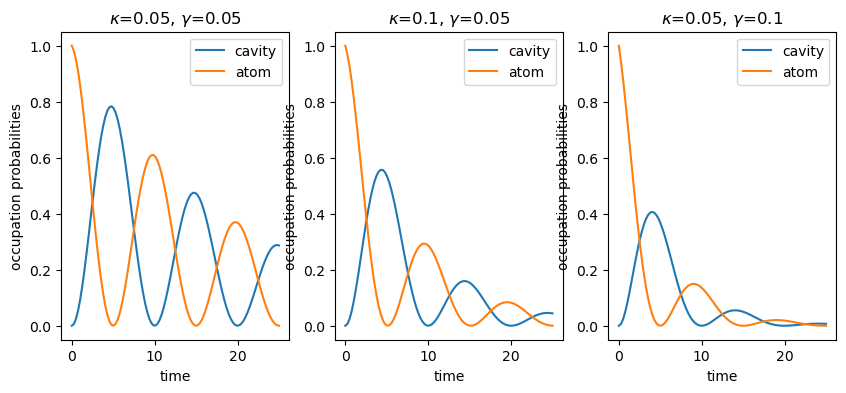

In [21]:
#change kappa and gamma, cavity and atom dissipation rate
c_ops1 = []
def cavity_dissipation(kappa):
    rate1 = kappa * (1 + n_th_a)
    if rate1 > 0:
        c_ops1.append(np.sqrt(rate1) * a)

def cavity_excitation(kappa):
    rate2 = kappa * n_th_a
    if rate2 > 0:
        c_ops1.append(np.sqrt(rate2) * a.dag())

def atom_dissipation(gamma):
    rate3 = gamma
    if rate3 > 0:
        c_ops1.append(np.sqrt(rate3) * sigmam)

def expectation_value(kappa, gamma):
    cavity_dissipation(kappa)
    cavity_excitation(kappa)
    atom_dissipation(gamma)
    result = mesolve(H, psi0, time, c_ops1, [a.dag() * a, sigmam.dag() * sigmam])
    n_c = result.expect[0]  #expectation value for cavity occupation number
    n_a = result.expect[1]  #expectation value for atom occupation number
    return n_c, n_a

n_c1, n_a1 = expectation_value(0.05, 0.05) #kappa = 0.05, gamma = 0.05
n_c2, n_a2 = expectation_value(0.1, 0.05)  #kappa = 0.1, gamma = 0.05
n_c3, n_a3 = expectation_value(0.05, 0.1)  #kappa = 0.05, gamma = 0.1
n_clist = [n_c1, n_c2, n_c3]
n_alist = [n_a1, n_a2, n_a3]

kappas = [0.05, 0.1, 0.05]
gammas = [0.05, 0.05, 0.1]

fig, axe = plt.subplots(1, 3, figsize = (10,4))
for i in range(0,3):
    axe[i].plot(time, n_clist[i], label = 'cavity')
    axe[i].plot(time, n_alist[i], label = 'atom')
    axe[i].legend(loc = 0)
    axe[i].set_xlabel('time')
    axe[i].set_ylabel('occupation probabilities')
    axe[i].set_title(f'$\kappa$={kappas[i]}, $\gamma$={gammas[i]}')
    
plt.show()

# Exercise 2

(i) Construct the single-junction Cooper Pair Box qubit Hamiltonian in 
QuTiP. <br>
(ii) Plot the single-junction CPB qubit spectrum as a function of offset
charge for different ${E_j}/{E_c}$ ratios. <br>
(iii) Modify the qubit hamiltonian for split-junction CPB and calculate
the transition energy $E_{01}$ as a function of applied flux. <br>
[QuTiP Lecture 11 - Charge Qubits](https://github.com/jrjohansson/qutip-lectures/blob/master/Lecture-11-Charge-Qubits.ipynb)

## Single-junction CPB Hamiltonian

The single-junction CPB qubit hamiltonian is given by: <br>
$\hat{H} = 4E_C\left(\hat{n}-n_g\right)^2-E_J\textrm{cos}\hat{\phi}$

Write a function that returns the qubit hamiltonian from given parameters $E_C$, $E_J$ and $n_g$. You will also need to define the charge space dimensions that the system will be evaluated in.

Tips: $e^{i\hat{\phi}}|{m}\rangle=|m-1\rangle$ and $e^{-i\hat{\phi}}|{m}\rangle=|m+1\rangle$. <br>
[quantum phase operator](https://journals.aps.org/ppf/pdf/10.1103/PhysicsPhysiqueFizika.1.49)

Type your codes here

In [22]:
N = 2
np.diag(np.ones(2*N), 1)

array([[0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.]])

In [23]:
destroy(5)

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         1.         0.         0.         0.        ]
 [0.         0.         1.41421356 0.         0.        ]
 [0.         0.         0.         1.73205081 0.        ]
 [0.         0.         0.         0.         2.        ]
 [0.         0.         0.         0.         0.        ]]

Check if your hamiltonian is hermitian using [isherm](https://qutip.org/docs/latest/apidoc/functions.html?highlight=isherm#qutip.qobj.isherm)

## Plot single-junction CPB spectrum

Given $E_C=230MHz$, $E_J=500MHz$ and $N=10$, solve the qubit's eigenenergies and plot the qubit spectrum as a function of $n_g$

Type your codes here

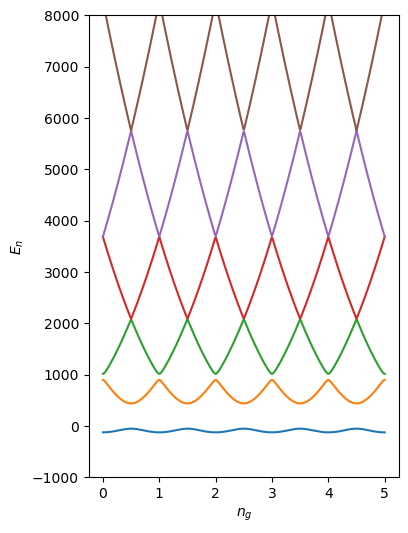

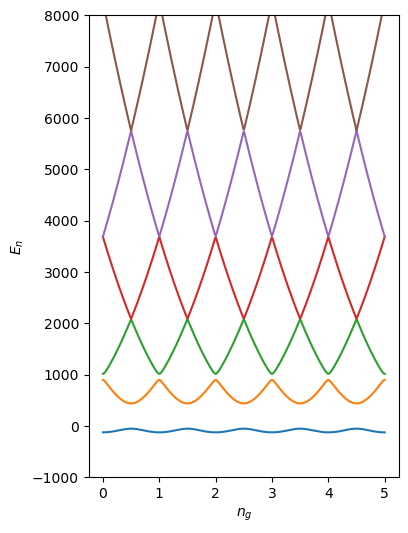

In [25]:
#get hamiltonian for cooper pair box
def get_hamiltonian(Ec, Ej, N, ng):
    #charging energy, energy cost of adding cooper pairs
    H_charging = np.diag(4*Ec*(np.arange(-N, N+1)-ng)**2)  #diagnal matrix with elements 4*Ec*(N-ng)^2
    #tunneling energy, energy of cooper pairs tunneling through the josephson junction
    upper_diag = np.diag(np.ones(2*N), 1)
    lower_diag = np.diag(np.ones(2*N), -1)
    H_tunneling = -0.5*Ej*(upper_diag+lower_diag)
    H = H_charging + H_tunneling 
    return Qobj(H)

#parameters
Ec = 230  #MHz
Ej = 500
N = 10

#solve for the whole spectrum
def plot_spectrum(ng_val, energy_val, ymax=(8000,3)):  #energy_val is the array of eigenenergies
    fig, axe = plt.subplots(figsize=(4,6))
    l = len(energy_val[0,:])  #length of eigenenergies
    for n in range (l):
        axe.plot(ng_val, energy_val[:,n])
    axe.set_ylim(-1000, ymax[0])
    axe.set_xlabel(r'$n_g$')
    axe.set_ylabel(r'$E_n$')
    return fig, axe

#obtain ng values and eigenenergy values
ng_val1 = np.linspace(0, 5, 500)
energy_val1 = np.array([get_hamiltonian(Ec, Ej, N, ng).eigenenergies() for ng in ng_val1])

plot_spectrum(ng_val1, energy_val1)
plt.show()

Now vary $E_J$ and check how the qubit spectrum changes as you increase $E_J$

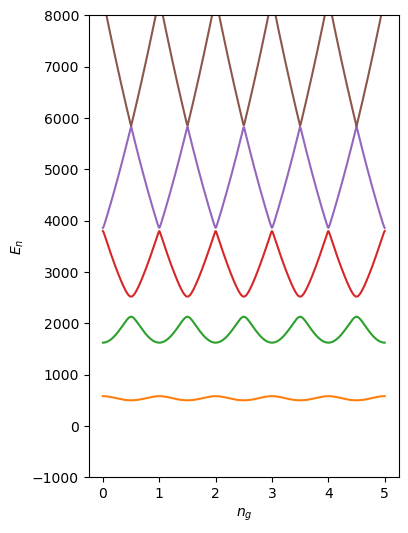

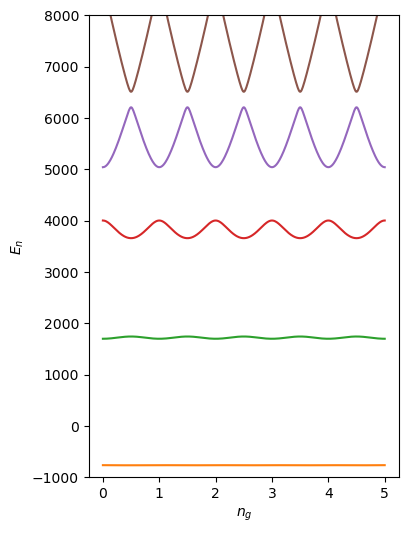

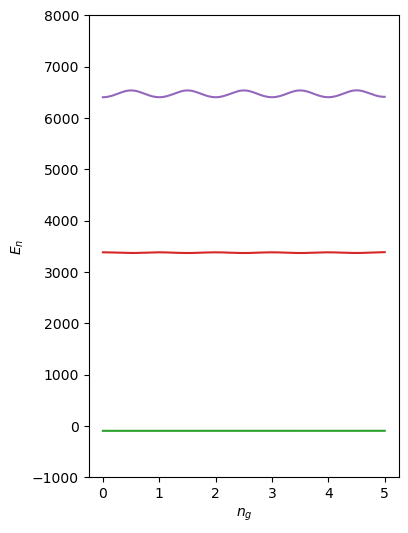

In [26]:
#varying Ej value, increasing Ej value until it hits the transmon regime
Ej2 = 2000
Ej3 = 5000
Ej4 = 10000  #transmon regime

ng_val1 = np.linspace(0, 5, 500)
energy_val2 = np.array([get_hamiltonian(Ec, Ej2, N, ng).eigenenergies() for ng in ng_val1])
energy_val3 = np.array([get_hamiltonian(Ec, Ej3, N, ng).eigenenergies() for ng in ng_val1])
energy_val4 = np.array([get_hamiltonian(Ec, Ej4, N, ng).eigenenergies() for ng in ng_val1])

plot_spectrum(ng_val1, energy_val2)
plot_spectrum(ng_val1, energy_val3)
plot_spectrum(ng_val1, energy_val4)

plt.show()

Write a function that extracts the $E_{01}$ transition at given $n_g$

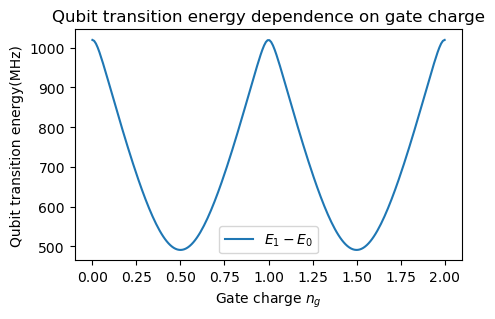

In [27]:
#solve for eigenenergies, and first transition energy
Ec = 230
Ej = 500
N = 10

ng_value = np.linspace(0, 2, 200)
E01_value = []

for ng in ng_value:
    H = get_hamiltonian(Ec, Ej, N, ng)  #hamiltonian
    e_value = H.eigenenergies()  #eigenenergies for hamiltonian
    E01_value.append(e_value[1] - e_value[0])  #first transition energy
    #energy difference between ground and first excited states

plt.figure(figsize=(5,3))
plt.plot(ng_value, E01_value, label = r'$E_1 - E_0$')
plt.xlabel(r'Gate charge $n_g$')
plt.ylabel('Qubit transition energy(MHz)')
plt.title('Qubit transition energy dependence on gate charge')
plt.legend()
plt.show()

Compare your simulated $E_{01}$ to the expression $\sqrt{8E_C E_J}$ when $E_J\gg E_C$

In [28]:
#compare the simulated E_01 with the theoretical expression of sqrt(8*Ec*Ej)
#simulated E_01 at ng=0.5
H1 = get_hamiltonian(Ec, Ej, N, 0.5)  #hamiltonian
e_value1 = H1.eigenenergies()  #eigenenergies for hamiltonian
E_01_experimental = e_value1[1] - e_value1[0]  #experimental first transition energy

E_01_theoretical = np.sqrt(8*Ec*Ej)  #theoretical first transiton energy

print('experimental first transiton energy:', E_01_experimental)
print('theoretical first transition energy:', E_01_theoretical)

experimental first transiton energy: 490.98204516799706
theoretical first transition energy: 959.1663046625439


## Split-junction CPB

Now if you include split-junction instead of a single junction in the CPB qubit, $E_J$ becomes flux-tunable. As a result, the qubit becomes flux-tunable as well. <br>

Given $E_J\left(\Phi\right) = E_{J}\sqrt{\textrm{cos}^2\left(\frac{\pi\Phi}{\Phi_0}\right)+d^2\textrm{sin}^2\left(\frac{\pi\Phi}{\Phi_0}\right)}$, modify your function of $E_{01}$ to include the flux tunability.

Type your codes here

In [29]:
#split junction CPB, where Ej becomes flux-tunable
#flux-tunable qubit
phi_0 = 1.0
phi_value = np.linspace(0,2,400)
E01_phi_value = []

Ec = 230
Ej = 500
N = 10
ng = 0  #offset charge
d = 0  #junction asymmetry

for phi in phi_value:
    cos_term = np.cos(np.pi*phi / phi_0)
    sin_term = np.sin(np.pi*phi / phi_0)
    #flux-dependent Ej, Ej_phi
    Ej_phi = Ej * np.sqrt(cos_term**2 + (d*sin_term)**2)

    #flux-dependent hamiltonian, H_phi
    H_phi_charging = np.diag(4*Ec*(np.arange(-N, N+1)-ng)**2)
    H_phi_tunneling = -0.5*Ej_phi*(np.diag(np.ones(2*N),1) + np.diag(np.ones(2*N), -1))
    H_phi = H_phi_charging + H_phi_tunneling 
    H_phi = Qobj(H_phi)

    #flux-dependent eigenenergies and first transition energy
    e_phi_value = H_phi.eigenenergies()
    E01_phi_value.append(e_phi_value[1] - e_phi_value[0])

E01_phi_value = np.array(E01_phi_value)


Given $d=0$ and $n_g=0$, plot $E_{01}$ as a function of applied flux $\Phi$

Type your codes here

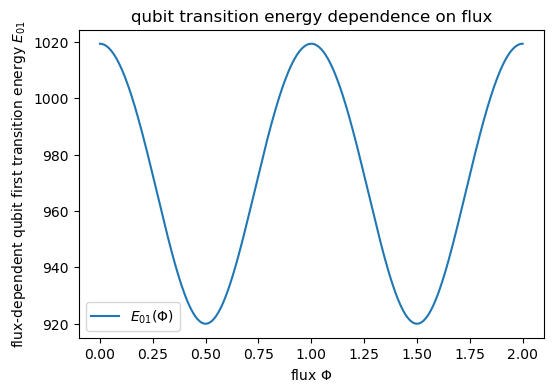

In [30]:
#plot
plt.figure(figsize=(6,4))
plt.plot(phi_value, E01_phi_value, label=r'$E_{01}(\Phi)$')
plt.xlabel(r'flux $\Phi$')
plt.ylabel(r'flux-dependent qubit first transition energy $E_{01}$')
plt.title('qubit transition energy dependence on flux')
plt.legend(loc=0)
plt.show()

Varying d and see how the flux tuneability depends on the asymmetry factor.

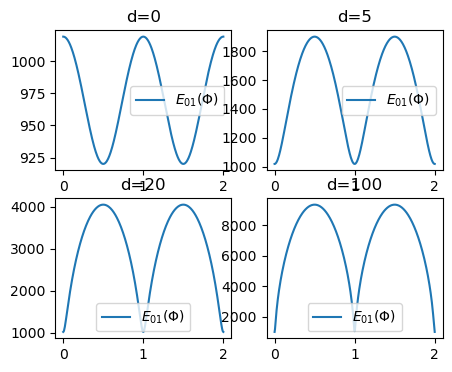

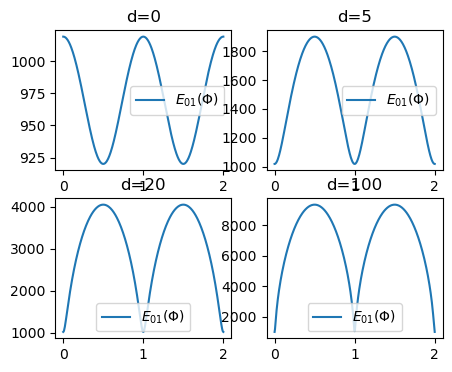

In [32]:
#varing d, the junction asymmetry factor
phi_0 = 1.0
phi_value = np.linspace(0,2,400)

Ec = 230
Ej = 500
N = 10
ng = 0

#hamiltonian dependence on d
def get_flux_hamiltonian(d):
    E01_phi_value = []
    for phi in phi_value:
        cos_term = np.cos(np.pi*phi / phi_0)
        sin_term = np.sin(np.pi*phi / phi_0)
        #flux-dependent Ej, Ej_phi
        Ej_phi = Ej * np.sqrt(cos_term**2 + (d*sin_term)**2)

        #flux-dependent hamiltonian, H_phi
        H_phi_charging = np.diag(4*Ec*(np.arange(-N, N+1)-ng)**2)
        H_phi_tunneling = -0.5*Ej_phi*(np.diag(np.ones(2*N),1) + np.diag(np.ones(2*N), -1))
        H_phi = H_phi_charging + H_phi_tunneling 
        H_phi = Qobj(H_phi)

        #flux-dependent eigenenergies and first transition energy
        e_phi_value = H_phi.eigenenergies()
        E01_phi_value.append(e_phi_value[1] - e_phi_value[0])
    E01_phi_value1 = np.array(E01_phi_value)
    return E01_phi_value1

#d=0, d=5, d=20, d=100 case
E01_phi_value1 = get_flux_hamiltonian(0)
E01_phi_value2 = get_flux_hamiltonian(5)
E01_phi_value3 = get_flux_hamiltonian(20)  
E01_phi_value4 = get_flux_hamiltonian(100)  
E01_list = [E01_phi_value1, E01_phi_value2, E01_phi_value3, E01_phi_value4]
d_list = [0, 5, 20, 100]

#plot
fig, axe = plt.subplots(2, 2, figsize=(5,4))
axe = axe.flatten()
for i in range(0,4):
    axe[i].plot(phi_value, E01_list[i], label=r'$E_{01}(\Phi)$')
    axe[i].legend()
    axe[i].set_title(f'd={d_list[i]}')
plt.show()

# Exercise 3

(i) Create the system where a split-junction CPB qubit is coupled to a
cavity. <br>
(ii)  Using the built-in function "spectrum" to simulate spectroscopic
measurements on the system.

## Qubit-cavity coupling

Given $E_J=50GHz$, $E_C=230MHz$, $d=0$, $n_g=0$, $g=80MHz$, $f_c=6GHz$, $\kappa=1e6$, $\gamma=1000e6$, $\bar{n}=0.1$, use the JCM model and $E_{01}$ function constructed in the previous exercises, create a system where a split-junction CPB is coupled to a cavity

Type your codes here

## Absorption spectrum

In cQED experiments we typically measure the absorption spectrum of the cavity in order to detect the qubit-cavity coupling. <br>

Assuming we are sweeping around the cavity frequency (say from 5.995GHz to 6.005GHz) while varying the applied flux $\Phi$, use the built-in function [spectrum](https://qutip.org/docs/latest/apidoc/functions.html?highlight=spectrum#qutip.correlation.spectrum)  in QuTiP to simulate the experimental outcome 

Type your codes here

Now change the value of the asymmetry factor d such that no matter what flux you applied, the qubit frequency is always above the cavity frequency. Simulate the absorption spectrum again and see what it looks like now.